In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayushus","key":"763b97d20f825f51f5057eeac16df17f"}'}

In [ ]:
#create kaggle directory and move the token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the chest X-ray pneumonia dataset from Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.26G/2.29G [00:18<00:00, 50.6MB/s]
100% 2.29G/2.29G [00:18<00:00, 133MB/s] 


In [ ]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#create destination folder nad unzip
import zipfile
import os

# Create a clean folder for the dataset
os.makedirs("pneumonia_dataset", exist_ok=True)

# Extract the zip file into that folder
with zipfile.ZipFile("chest-xray-pneumonia.zip", 'r') as zip_ref:
    zip_ref.extractall("pneumonia_dataset")


In [ ]:
#checking extracted folder structure
import os

# List contents of the pneumonia_dataset directory
os.listdir("pneumonia_dataset")


['chest_xray']

In [ ]:
#checking contents inside chest_xray
os.listdir("pneumonia_dataset/chest_xray")

['__MACOSX', 'chest_xray', 'train', 'test', 'val']

In [ ]:
# Count number of images in each subfolder
for folder in ['train', 'val', 'test']:
    path = f"pneumonia_dataset/chest_xray/{folder}"
    normal_count = len(os.listdir(os.path.join(path, "NORMAL")))
    pneumonia_count = len(os.listdir(os.path.join(path, "PNEUMONIA")))
    print(f"{folder.upper()} → NORMAL: {normal_count}, PNEUMONIA: {pneumonia_count}")


TRAIN → NORMAL: 1341, PNEUMONIA: 3875
VAL → NORMAL: 8, PNEUMONIA: 8
TEST → NORMAL: 234, PNEUMONIA: 390


In [ ]:
#directory path set
train_dir = "pneumonia_dataset/chest_xray/train"
test_dir = "pneumonia_dataset/chest_xray/test"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create one generator with validation split
datagen = ImageDataGenerator(
    rescale=1./255, #rescaling
    #data augmentation
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',

    validation_split=0.2  # 👈 This splits 80% train, 20% val
)

# Training generator (80%)
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'  # 👈 80% of images
)

# Validation generator (20%)
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # 👈 20% of images
)

# Test generator (remains unchanged)
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
#load VGG16 base without top layer
from tensorflow.keras.applications import VGG16

# Load VGG16 base model without classifier layers
base_model = VGG16(
    weights='imagenet',         # Pretrained on ImageNet
    include_top=False,          # Remove the default FC layers
    input_shape=(224, 224, 3)   # Input shape of our X-ray images
)

# Freeze the base model so its weights don't update during training
base_model.trainable = False


In [ ]:
#add custom layers on top of VGG16
from tensorflow.keras import layers, models

# Build the model
model = models.Sequential([
    base_model,
    layers.Flatten(),                      # Flatten feature maps
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),                   # Prevent overfitting
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])


In [ ]:
#compile the model
from tensorflow.keras.optimizers import Adam

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)


In [ ]:
#view model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25088)          │       100,352 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,239,105 (81.02 MB)

 Trainable params: 6,473,729 (24.70 MB)

 Non-trainable params: 14,765,376 (56.33 MB)

In [ ]:
#steup callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Save the best model during training
checkpoint = ModelCheckpoint(
    "best_vgg16_model.h5", monitor='val_accuracy',
    save_best_only=True, mode='max', verbose=1
)

# Stop training if val_loss doesn't improve for 3 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True, verbose=1
)


In [ ]:
#training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.8398 - loss: 0.4163
Epoch 1: val_accuracy improved from -inf to 0.92809, saving model to best_vgg16_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 144s 972ms/step - accuracy: 0.8401 - loss: 0.4156 - val_accuracy: 0.9281 - val_loss: 0.2756
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.9350 - loss: 0.2284
Epoch 2: val_accuracy improved from 0.92809 to 0.96165, saving model to best_vgg16_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 802ms/step - accuracy: 0.9350 - loss: 0.2283 - val_accuracy: 0.9616 - val_loss: 0.1588
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9475 - loss: 0.1697
Epoch 3: val_accuracy did not improve from 0.96165
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.9476 - loss: 0.1697 - val_accuracy: 0.9540 - val_loss: 0.1397
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.9549 - loss: 0.1429
Epoch 4: val_accuracy improved from 0.96165 to 0.96261, saving model to best_vgg16_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 810ms/step - accuracy: 0.9549 - loss: 0.1429 - val_accuracy: 0.9626 - val_loss: 0.1157
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.9502 - loss: 0.1673
Epoch 5: val_accuracy improved from 0.96261 to 0.96644, saving model to best_vgg16_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 806ms/step - accuracy: 0.9502 - loss: 0.1672 - val_accuracy: 0.9664 - val_loss: 0.1067
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.9599 - loss: 0.1199
Epoch 6: val_accuracy improved from 0.96644 to 0.97603, saving model to best_vgg16_model.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 126s 965ms/step - accuracy: 0.9599 - loss: 0.1199 - val_accuracy: 0.9760 - val_loss: 0.0917
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.9608 - loss: 0.1153
Epoch 7: val_accuracy did not improve from 0.97603
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 804ms/step - accuracy: 0.9608 - loss: 0.1154 - val_accuracy: 0.9741 - val_loss: 0.0951
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.9744 - loss: 0.0934
Epoch 8: val_accuracy did not improve from 0.97603
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 799ms/step - accuracy: 0.9744 - loss: 0.0935 - val_accuracy: 0.9674 - val_loss: 0.1049
Epoch 9/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.9650 - loss: 0.1176
Epoch 9: val_accuracy did not improve from 0.97603
131/131 ━━━━━━━━━━━━━━━━━━━━ 126s 962ms/step - accuracy: 0.9650 - loss: 0.1176 - val_accuracy: 0.9722 - val_loss: 0.0917
Epoch 10/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.9623 - loss: 0.1158
Epoch 10: 

In [ ]:
#load the best model
from tensorflow.keras.models import load_model

model = load_model("best_vgg16_model.h5")
print("✅ Best model loaded successfully!")


✅ Best model loaded successfully!


In [ ]:
#evaluate the test
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 597ms/step - accuracy: 0.8152 - loss: 0.5580
Test Accuracy: 0.8846
Test Loss: 0.3685


In [ ]:
#generate prediction
import numpy as np

y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step


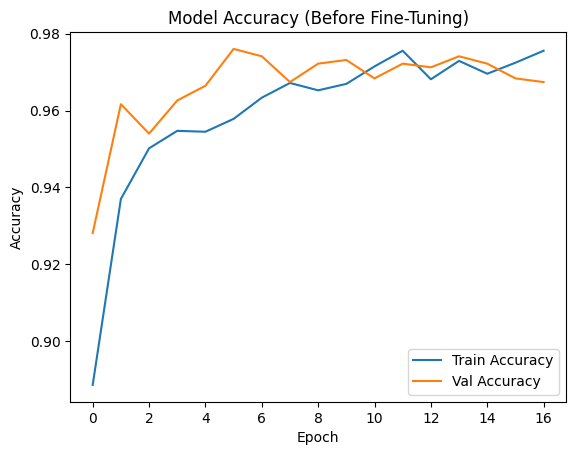

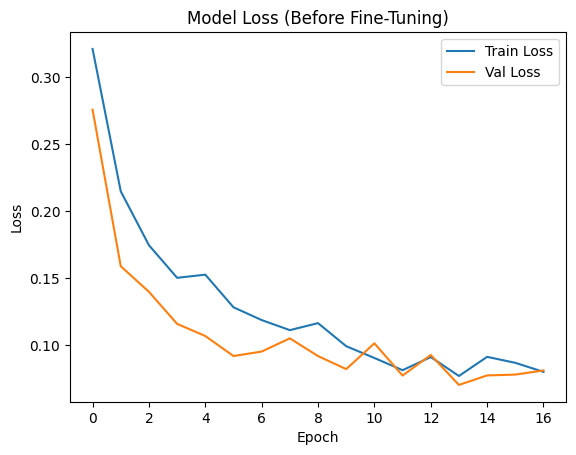

In [ ]:
#plot training accuracy and loss
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy (Before Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("\n")

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss (Before Fine-Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
model = tf.keras.models.load_model("best_vgg16_model.h5")


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25088)          │       100,352 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,239,107 (81.02 MB)

 Trainable params: 6,473,729 (24.70 MB)

 Non-trainable params: 14,765,376 (56.33 MB)

 Optimizer params: 2 (12.00 B)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 268ms/step


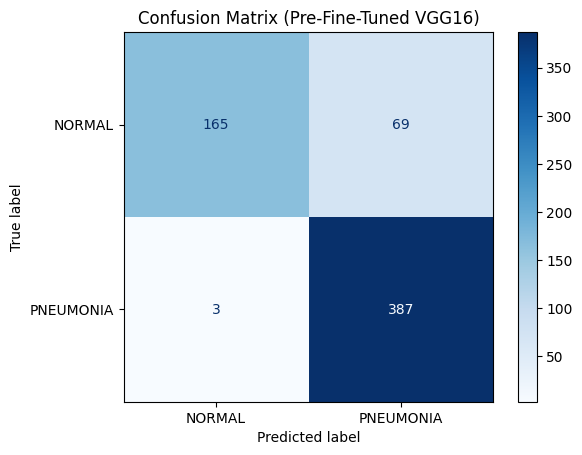


Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.98      0.71      0.82       234
   PNEUMONIA       0.85      0.99      0.91       390

    accuracy                           0.88       624
   macro avg       0.92      0.85      0.87       624
weighted avg       0.90      0.88      0.88       624



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int)

# True labels
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Pre-Fine-Tuned VGG16)")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["NORMAL", "PNEUMONIA"]))


In [ ]:
model.save("vgg16_base_model.h5")


In [ ]:
from google.colab import files
files.download("vgg16_base_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>